In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import json
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.likelihood
import cogwheel.data
from cogwheel.plotting import latex_val_err
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors
import gwosc
import gwpy.table
from pesummary.io import read

sys.path.insert(0, '../code')
import make_event_data
from parameter_estimation import get_chirp_mass, get_table_data, add_derived_quantities, get_event_data, load_posterior_samples, load_lvk_samples

In [3]:
# helper function to get median values
def get_medians(samples, corner_plot):
    medians = {}
    for key in samples.keys():
        medians[key] = corner_plot._get_median_and_central_interval(key)[0]
    return medians

In [4]:
# load samples from event posterior(s)

# where we've saved the posteriors and samples
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'

# list of event directories
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 24 events


In [5]:
def plot_p_lensed(samples, eventname=None, fig=None, **kwargs):
    cp = cogwheel.gw_plotting.CornerPlot(
        samples, params=['p_lensed'], tail_probability=1e-4
    )
    hist, edges = np.histogram(samples['p_lensed'], bins=100,
                               weights=samples['weights'])
    # we want the pdf at edges, not midpoints:
    pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])
    
    if fig is None:
        fig, ax = plt.subplots(figsize=(5,4))
    else:
        fig, ax = fig, plt.gca()
    ax.plot(edges, pdf, c='navy', alpha=0.9, **kwargs)
    ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
    ax.set_xlabel('p_lensed')
    ax.set_xlim(0., 1.)
    ax.set_ylim(0., None)
    
    # vlines
    median, *span = cp._get_median_and_central_interval('p_lensed')
    for val in (median, *span):
        ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c='navy', alpha=0.8, lw=0.5)
    idx = (edges > span[0]) & (edges < span[1])
    ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color='navy', alpha=0.1)
    val_err_str = '${}={}$' + latex_val_err(median, np.subtract(median, span))
    title_str = "p_lensed" if eventname is None else f"{eventname}: p_lensed"
    ax.set_title(title_str + val_err_str)

In [6]:
# plot parameters for our cogwheel results:
plot_params = [
    'mchirp',
    'm1',
    'm2',
    'chieff',
    'd_luminosity',
    'ra',
    'dec',
    'p_lensed'
]

In [7]:
# number of resamples
n_resamples = 1000

loaded posterior samples for GW230518_125908 run 0


2026-01-28  13:54:35 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-28  13:54:35 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-28  13:54:35 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-28  13:54:35 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-28  13:54:35 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Currently only the IMRPhenomNSBH waveform model can be used. Unable to calculate the NSBH conversion
2026-01-28  13:54:35 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Current

loaded posterior samples for GW230628_231200 run 1
loaded posterior samples for GW230924_124453 run 0
couldn't find any LVK samples for GW230924_124453 (in GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW231108_125142 run 0
couldn't find any LVK samples for GW231108_125142 (in GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW231206_233134 run 0
couldn't find any LVK samples for GW231206_233134 (in GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW230630_234532 run 0
couldn't find any LVK samples for GW230630_234532 (in GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW231206_233901 run 0
loaded posterior samples for GW231028_153006 run 0
loaded posterior samples for GW190814_211039 run 0
loaded posterior samples for GW230914_111401 run 0
loaded posterior samples for GW240104_164932 run 0
loaded posterior samples for GW231226_101520 run 0
loaded posterior samples for GW230814_230901 run 0
loaded posterior samples for GW230922_020344 run 0
couldn't find any LVK samples for

2026-01-28  13:55:39 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


could not find posterior samples for GW231123_135430 in ../data/pe_runs_lensing/IntrinsicLVCPrior/GW231123_135430
loaded posterior samples for GW230927_043729 run 0
couldn't find any LVK samples for GW230927_043729 (in GWTC-4.0 or GWTC-2.1)


/local/abbye.williams/ipykernel_536208/3302775786.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5,4))


loaded posterior samples for GW230922_040658 run 0
couldn't find any LVK samples for GW230922_040658 (in GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW230927_153832 run 0


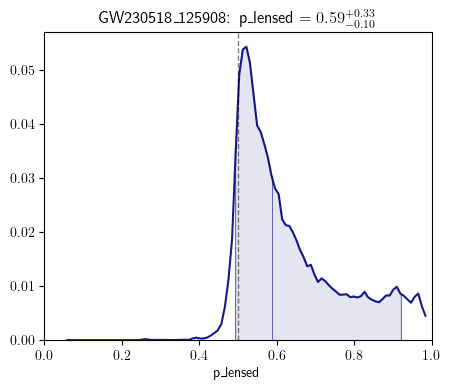

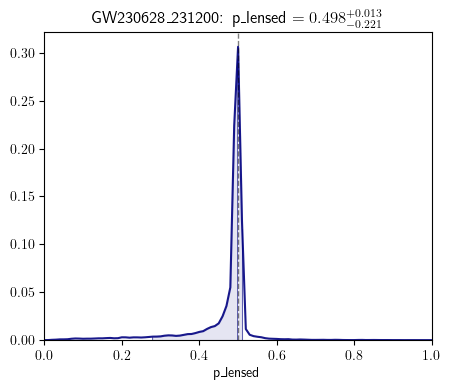

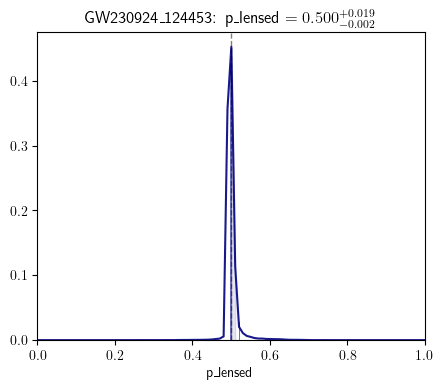

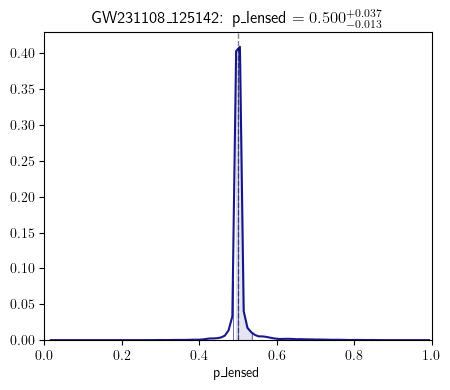

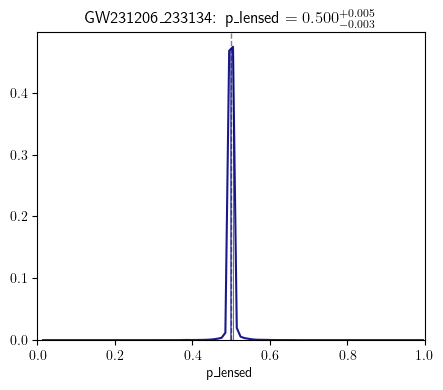

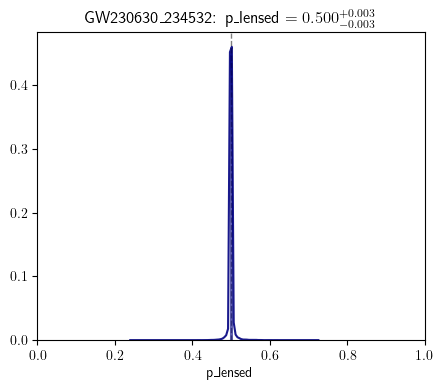

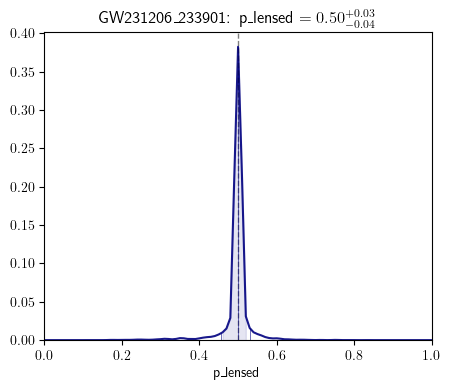

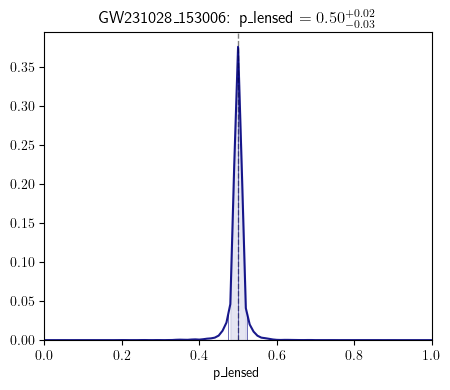

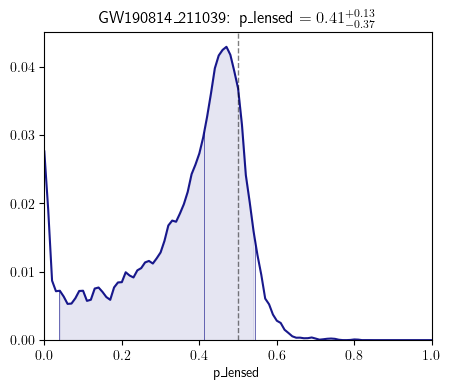

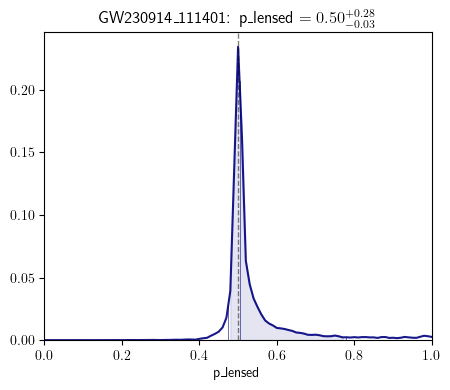

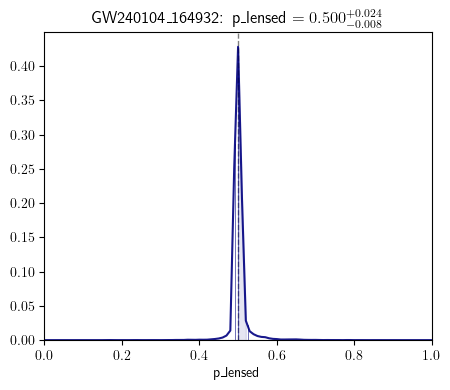

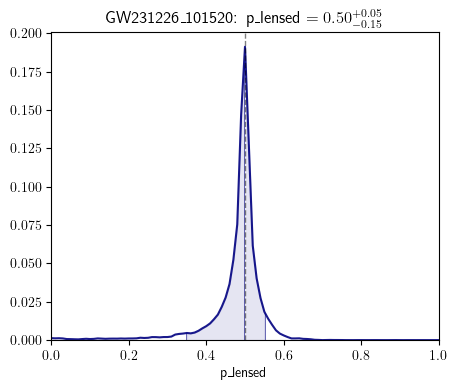

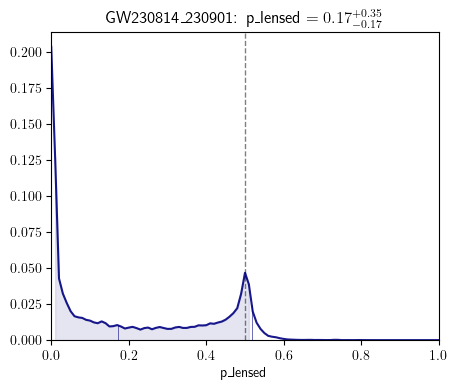

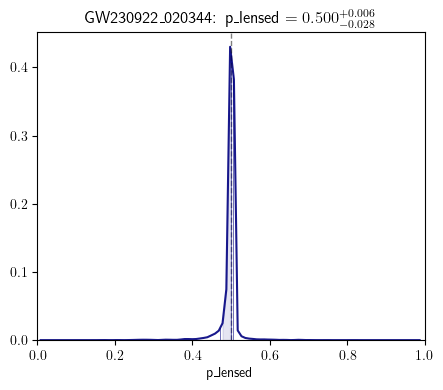

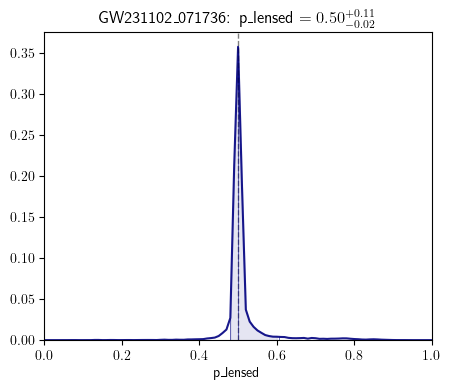

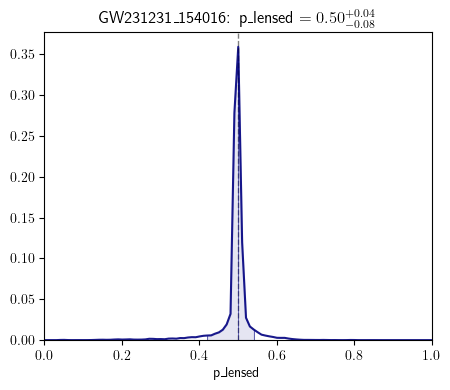

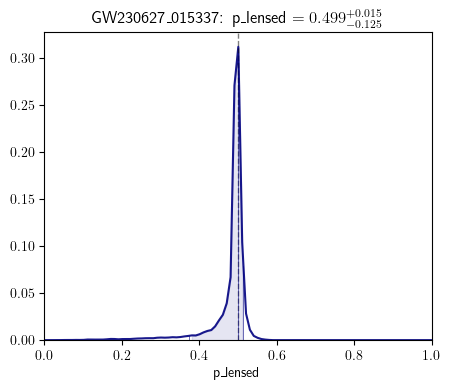

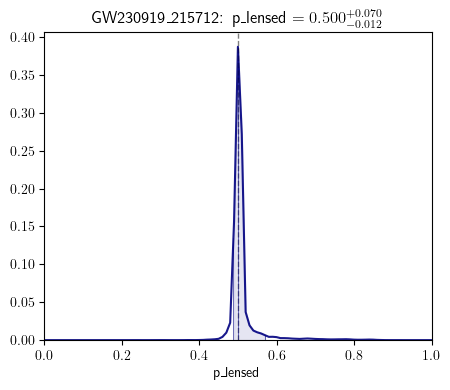

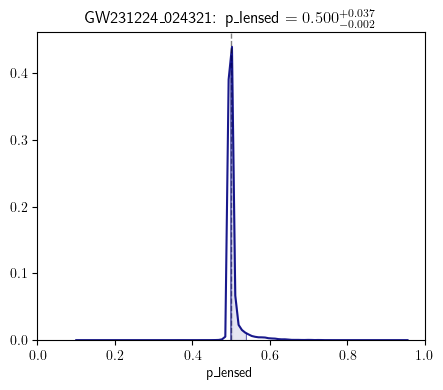

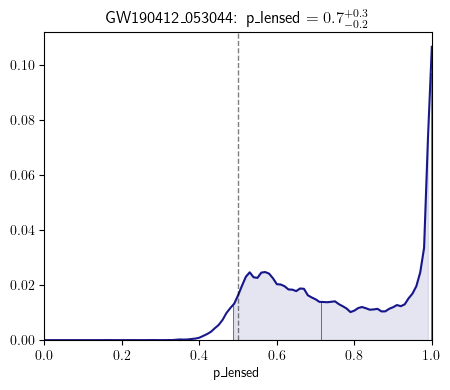

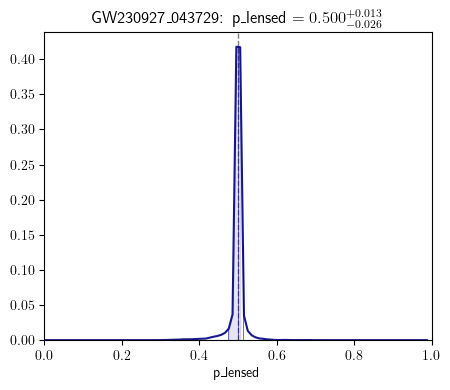

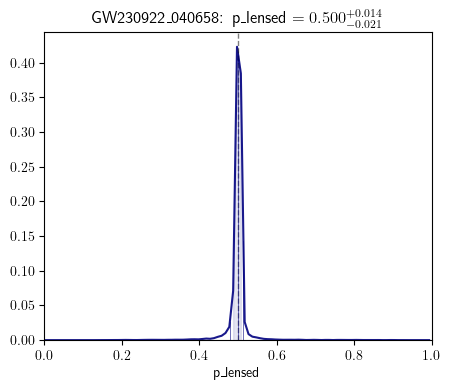

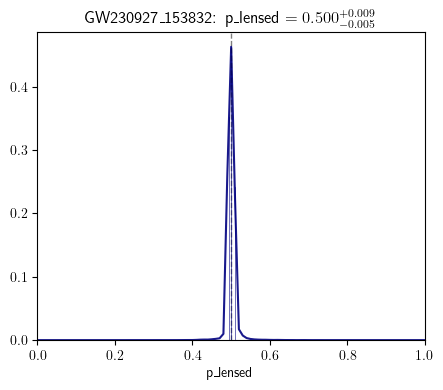

In [16]:
bayes_factors = {}
for (eventname, event_path) in zip(eventname_list, event_dir_list):
    samples = load_posterior_samples(eventname, event_path)
    if samples is None:
        continue
    samples_lvk = load_lvk_samples(eventname)

    # plot the p_lensed distribution
    plot_p_lensed(samples, eventname=eventname)

    # and compute Bayes factor and uncertainty
    bayes_factors_ = bootstrap_bayes_factors(samples, n_resamples)
    bayes_factors[eventname] = (np.median(bayes_factors_), np.std(bayes_factors_))

In [17]:
for eventname, (median, std) in bayes_factors.items():
    print(f"{eventname}:\t{median:.4f} +- {std:.4f}")

GW230518_125908:	1.7275 +- 0.0112
GW230628_231200:	0.8811 +- 0.0023
GW230924_124453:	1.0117 +- 0.0006
GW231108_125142:	1.0182 +- 0.0012
GW231206_233134:	1.0014 +- 0.0003
GW230630_234532:	1.0003 +- 0.0002
GW231206_233901:	0.9881 +- 0.0015
GW231028_153006:	0.9971 +- 0.0008
GW190814_211039:	0.5812 +- 0.0041
GW230914_111401:	1.1822 +- 0.0052
GW240104_164932:	1.0113 +- 0.0009
GW231226_101520:	0.9217 +- 0.0024
GW230814_230901:	0.2889 +- 0.0033
GW230922_020344:	0.9857 +- 0.0010
GW231102_071736:	1.0490 +- 0.0027
GW231231_154016:	0.9762 +- 0.0020
GW230627_015337:	0.9243 +- 0.0020
GW230919_215712:	1.0404 +- 0.0016
GW231224_024321:	1.0224 +- 0.0008
GW190412_053044:	2.8354 +- 0.0238
GW230927_043729:	0.9920 +- 0.0009
GW230922_040658:	0.9965 +- 0.0011
GW230927_153832:	1.0026 +- 0.0004


### the two events from Javier: GW190412 and GW190814

In [18]:
eventname_list_subset = ['GW190412', 'GW190814']
event_dir_subset = np.array([glob.glob(f'{resdir}/{x}*') for x in eventname_list_subset]).flatten()

loaded posterior samples for GW190412 run 0
couldn't find any LVK samples for GW190412 (in GWTC-4.0 or GWTC-2.1)
GW190412:	2.8358 +- 0.0226
loaded posterior samples for GW190814 run 0
couldn't find any LVK samples for GW190814 (in GWTC-4.0 or GWTC-2.1)
GW190814:	0.5808 +- 0.0042


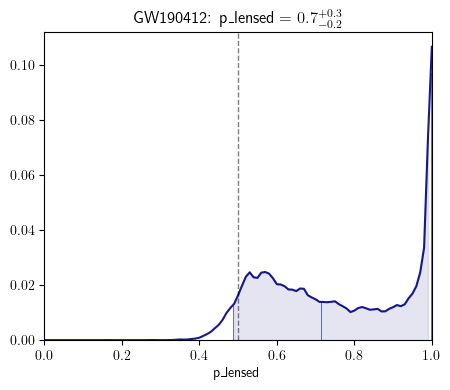

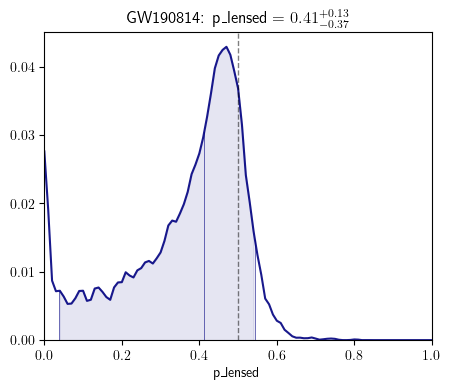

In [19]:
for (eventname, event_path) in zip(eventname_list_subset, event_dir_subset):
    samples = load_posterior_samples(eventname, event_path)
    if samples is None:
        continue
    samples_lvk = load_lvk_samples(eventname)

    # plot the p_lensed distribution
    plot_p_lensed(samples, eventname=eventname)

    # and compute Bayes factor and uncertainty
    bayes_factors_ = bootstrap_bayes_factors(samples, n_resamples)
    print(f"{eventname}:\t{np.median(bayes_factors_):.4f} +- {np.std(bayes_factors_):.4f}")

#### what if we multiply the GW230814_230901 waveform by $i$? do we get a symmetric `p_lensed` distribution?

In [11]:
eventname = 'GW230814_230901'

# load the results for the original event data to compare
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'
event_path = os.path.join(resdir, eventname)
samples, _ = load_posterior_samples(eventname, event_path)

# and now load the results for the strain data multiplied by i
resdir = '../data/pe_runs_lensing/multiplied_by_i/IntrinsicLVCPrior'
event_path = os.path.join(resdir, eventname)
samples_i, _ = load_posterior_samples(eventname, event_path)

loaded posterior samples for GW230814_230901 run 0
loaded posterior samples for GW230814_230901 run 0


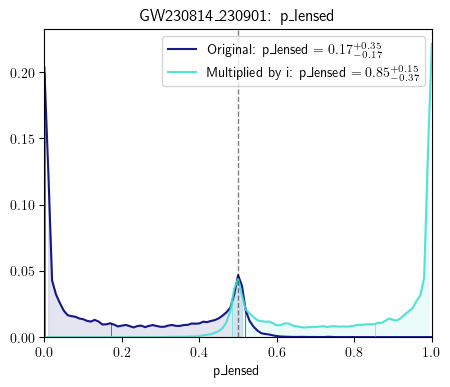

In [12]:
fig, ax = plt.subplots(figsize=(5,4))
cs = ['navy', 'turquoise']
labels = ['Original: p_lensed', 'Multiplied by i: p_lensed']
for i, samples_ in enumerate([samples, samples_i]):
    cp = cogwheel.gw_plotting.CornerPlot(
        samples_, params=['p_lensed'], tail_probability=1e-4
    )
    hist, edges = np.histogram(samples_['p_lensed'], bins=100,
                                weights=samples_['weights'])
    # we want the pdf at edges, not midpoints:
    pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])

    # vlines
    median, *span = cp._get_median_and_central_interval('p_lensed')
    for val in (median, *span):
        ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c=cs[i], alpha=0.8, lw=0.5)
    idx = (edges > span[0]) & (edges < span[1])
    ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color=cs[i], alpha=0.1)
    val_err_str = '${}={}$' + latex_val_err(median, np.subtract(median, span))

    # plot the histogram
    ax.plot(edges, pdf, c=cs[i], alpha=0.9, label=labels[i] + val_err_str)

ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
ax.set_xlabel('p_lensed')
ax.set_xlim(0., 1.)
ax.set_ylim(0., None)
ax.set_title(f"{eventname}: p_lensed")
ax.legend()